## Libraries

In [1]:
!pip install -q \
  datasets \
  transformers \
  peft \
  huggingface_hub \
  ipywidgets

!pip install -U bitsandbytes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.2/491.2 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.9/183.9 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.5/143.5 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 44.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 59.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 25.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
import os
import sys
import time
import torch
import random
import ipywidgets
import pandas as pd
from datetime import datetime
from torch.utils.data import Dataset
from datasets import load_dataset
from peft import LoraConfig, get_peft_model, TaskType, PeftModel
from itertools import islice
import matplotlib.pyplot as plt
from IPython.display import clear_output, display, update_display, DisplayHandle
from huggingface_hub import login, HfFolder, HfApi, hf_hub_download, delete_repo, list_repo_files, snapshot_download
from transformers import AutoTokenizer, AutoModelForCausalLM, TrainingArguments, Trainer, BitsAndBytesConfig, TrainerCallback
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True,max_split_size_mb:32" # Allows to split memory into pieces when allocating (normally the GPU VRAM needs a contiguous block of memory). Caps memory block size to maximum of 32 MB

## Load model & dataset

##### Login to huggingface

In [3]:
login()

#### Load base model

The GPU VRAM is not sufficient for training the model. We use LoRA to make it more efficient

In [ ]:
# Use only for loading new tinyllama model

"""

# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained("TinyLlama/TinyLlama-1.1B-Chat-v1.0")

# Load model with 8-bit quantization
model = AutoModelForCausalLM.from_pretrained(
    "TinyLlama/TinyLlama-1.1B-Chat-v1.0",
    load_in_8bit=True,               # 8-bit quantization
    device_map="auto"                # Automatically place layers on GPU/CPU
)

# Define LoRA configuration
lora_config = LoraConfig(
    r=8,
    lora_alpha=16,
    target_modules=["q_proj", "v_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type=TaskType.CAUSAL_LM
)

# Apply LoRA to the quantized model
model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

"""

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/1.29k [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.84M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/551 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/608 [00:00<?, ?B/s]

The `load_in_4bit` and `load_in_8bit` arguments are deprecated and will be removed in the future versions. Please, pass a `BitsAndBytesConfig` object in `quantization_config` argument instead.


model.safetensors:   0%|          | 0.00/2.20G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

trainable params: 1,126,400 || all params: 1,101,174,784 || trainable%: 0.1023


#### Load fine-tuned model with LoRA adapters

In [4]:
# Load base model
base = AutoModelForCausalLM.from_pretrained(
    "TinyLlama/TinyLlama-1.1B-Chat-v1.0",
    load_in_8bit=True,        # 8-bit quantization
    device_map="auto"
)

# Load your previously trained LoRA adapter (set as trainable)
model = PeftModel.from_pretrained(
    base,
    "eduhuemar001/tinyllama-german",
    is_trainable=True         # Required for continued training
)

# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained("TinyLlama/TinyLlama-1.1B-Chat-v1.0")

model.print_trainable_parameters()  # Only LoRA layers should be trainable
print(model.base_model_prefix)
print(model)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/608 [00:00<?, ?B/s]

The `load_in_4bit` and `load_in_8bit` arguments are deprecated and will be removed in the future versions. Please, pass a `BitsAndBytesConfig` object in `quantization_config` argument instead.


model.safetensors:   0%|          | 0.00/2.20G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/1.29k [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.84M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/551 [00:00<?, ?B/s]

trainable params: 1,126,400 || all params: 1,101,174,784 || trainable%: 0.1023
model
PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): LlamaForCausalLM(
      (model): LlamaModel(
        (embed_tokens): Embedding(32000, 2048)
        (layers): ModuleList(
          (0-21): 22 x LlamaDecoderLayer(
            (self_attn): LlamaAttention(
              (q_proj): lora.Linear8bitLt(
                (base_layer): Linear8bitLt(in_features=2048, out_features=2048, bias=False)
                (lora_dropout): ModuleDict(
                  (default): Dropout(p=0.05, inplace=False)
                )
                (lora_A): ModuleDict(
                  (default): Linear(in_features=2048, out_features=8, bias=False)
                )
                (lora_B): ModuleDict(
                  (default): Linear(in_features=8, out_features=2048, bias=False)
                )
                (lora_embedding_A): ParameterDict()
                (lora_embedding_B): ParameterDict()
           

#### Load dataset

In [5]:
# Seed with a truly random int so the stream starts at a different offset every run
random.seed()
skip_count = random.randint(0, 1_000_000)

streamed_dataset = load_dataset(
    "wikipedia",
    "20220301.de",
    split="train",
    streaming=True,
    trust_remote_code=True
)

# Skip ahead to a random position in the stream
streamed_dataset = islice(streamed_dataset, skip_count, skip_count + 500)
dataset = list(streamed_dataset)

token_counts = [len(tokenizer.encode(item["text"])) for item in dataset]
total_tokens = sum(token_counts)
print(f"Total tokens: {total_tokens:,}")
print(f"Avg tokens per article: {total_tokens / len(dataset):.2f}")

README.md:   0%|          | 0.00/16.0k [00:00<?, ?B/s]

wikipedia.py:   0%|          | 0.00/36.7k [00:00<?, ?B/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (2170 > 2048). Running this sequence through the model will result in indexing errors


Total tokens: 582,145
Avg tokens per article: 1164.29


## Preprocessing

#### Tokenize data

Each subword is being converted to a token with a byte pair encoder

In [6]:
tokens = []

for item in dataset:
    ids = tokenizer(item["text"], return_attention_mask=False, add_special_tokens=False).input_ids
    tokens.extend(ids + [tokenizer.eos_token_id])  # optional: add EOS after each article

#### Split tokens into chunks



Documents with a high amount of tokens exceed the maximum context window of 2048 tokens. The documents are split up into chunks of 128 tokens.

In [7]:
block_size = 128
total_length = len(tokens) - (len(tokens) % block_size)
tokens = tokens[:total_length] # Ensure the tokens array has a length of multiple of block size

chunks = [tokens[i:i + block_size] for i in range(0, total_length, block_size)] # Split tokens into chunks

#### Prepare chunks for training

In [8]:
class ChunkDataset(Dataset):
    def __init__(self, chunks):
        self.chunks = chunks

    def __len__(self):
        return len(self.chunks)

    def __getitem__(self, idx):
        ids = torch.tensor(self.chunks[idx], dtype=torch.long)
        return {
            "input_ids": ids,
            "labels": ids
        }

train_dataset = ChunkDataset(chunks)

## Logging & Plotting

#### Load previous logs

In [9]:
HF_LOG_REPO_ID = "eduhuemar001/tinyllama-german"
LOG_SUBDIR = "logs"

timestamp = datetime.now().strftime("%Y%m%d_%H%M")
logfile_name = f"loss_log_{timestamp}.csv"
remote_log_path = f"{LOG_SUBDIR}/{logfile_name}"
local_log_path = f"/content/{logfile_name}"

api = HfApi()
total_logged_steps = 0
all_logs = []

for file in list_repo_files(HF_LOG_REPO_ID, repo_type="model"):
    if file.startswith(LOG_SUBDIR) and file.endswith(".csv"):
        try:
            local_path = hf_hub_download(
                repo_id=HF_LOG_REPO_ID,
                repo_type="model",
                filename=file,
                local_dir="/content",
                local_dir_use_symlinks=False
            )
            df = pd.read_csv(local_path)
            all_logs.append(df)
            if not df.empty:
                step_max = df["global_step"].max()
                if step_max > total_logged_steps:
                    total_logged_steps = step_max
        except:
            print(f"Failed to load: {file}")

/usr/local/lib/python3.11/dist-packages/huggingface_hub/file_download.py:933: UserWarning: `local_dir_use_symlinks` parameter is deprecated and will be ignored. The process to download files to a local folder has been updated and do not rely on symlinks anymore. You only need to pass a destination folder as`local_dir`.
For more details, check out https://huggingface.co/docs/huggingface_hub/main/en/guides/download#download-files-to-local-folder.
  warnings.warn(


loss_log_20250421_1705.csv:   0%|          | 0.00/991 [00:00<?, ?B/s]

/usr/local/lib/python3.11/dist-packages/huggingface_hub/file_download.py:933: UserWarning: `local_dir_use_symlinks` parameter is deprecated and will be ignored. The process to download files to a local folder has been updated and do not rely on symlinks anymore. You only need to pass a destination folder as`local_dir`.
For more details, check out https://huggingface.co/docs/huggingface_hub/main/en/guides/download#download-files-to-local-folder.
  warnings.warn(


loss_log_20250421_1738.csv:   0%|          | 0.00/1.21k [00:00<?, ?B/s]

/usr/local/lib/python3.11/dist-packages/huggingface_hub/file_download.py:933: UserWarning: `local_dir_use_symlinks` parameter is deprecated and will be ignored. The process to download files to a local folder has been updated and do not rely on symlinks anymore. You only need to pass a destination folder as`local_dir`.
For more details, check out https://huggingface.co/docs/huggingface_hub/main/en/guides/download#download-files-to-local-folder.
  warnings.warn(


loss_log_OLD_20240420.csv:   0%|          | 0.00/2.10k [00:00<?, ?B/s]

#### Create logging callback

In [10]:
class LossLoggingCallback(TrainerCallback):
    def __init__(self, local_path, remote_path, repo_id, step_offset=0, flush_every_n_steps=50):
        self.local_path = local_path
        self.remote_path = remote_path
        self.repo_id = repo_id
        self.step_offset = step_offset
        self.flush_every_n_steps = flush_every_n_steps
        self.losses = []

    def on_log(self, args, state, control, logs=None, **kwargs):
        if logs and "loss" in logs:
            step = state.global_step + self.step_offset
            loss = logs["loss"]
            self.losses.append((step, loss))

            # Flush log every N steps (e.g. every 50)
            if step % self.flush_every_n_steps == 0:
                self._flush_log(step)

    def on_save(self, args, state, control, **kwargs):
        # Final flush on checkpoint save
        if self.losses:
            self._flush_log(state.global_step)

    def on_train_end(self, args, state, control, **kwargs):
        # Final flush at the end of training
        if self.losses:
            self._flush_log(state.global_step)

    def _flush_log(self, current_step):
        try:
            df = pd.DataFrame(self.losses, columns=["global_step", "training_loss"])
            df.to_csv(self.local_path, index=False)

            api = HfApi()
            api.upload_file(
                path_or_fileobj=self.local_path,
                path_in_repo=self.remote_path,
                repo_id=self.repo_id,
                repo_type="model",
                commit_message=f"Auto-flushed loss log at step {current_step}"
            )
            print(f"Loss log flushed to Hugging Face at step {current_step}")
        except Exception as e:
            print(f"Failed to upload loss log at step {current_step}: {e}")

#### Create real-time plotting callback

In [11]:
class LiveLossPlotCallback(TrainerCallback):
    def __init__(self, base_logs=None, step_offset=0, gap_threshold=500):
        self.df_history = pd.concat(base_logs, ignore_index=True) if base_logs else pd.DataFrame(columns=["global_step", "training_loss"])
        self.step_offset = step_offset
        self.gap_threshold = gap_threshold
        self.new_data = []
        self.display_handle_full = None
        self.display_handle_current = None

    def _render_plots(self):
        # Create cumulative DataFrame
        df_all = pd.concat([
            self.df_history,
            pd.DataFrame([(s + self.step_offset, l) for s, l in self.new_data], columns=["global_step", "training_loss"])
        ], ignore_index=True)

        df_all.sort_values("global_step", inplace=True)

        # Insert NaNs where step gaps exceed threshold
        step_diff = df_all["global_step"].diff()
        gap_indices = step_diff[step_diff > self.gap_threshold].index

        for idx in gap_indices[::-1]:  # reverse so indexes don't shift
            df_all = pd.concat([
                df_all.iloc[:idx],
                pd.DataFrame({"global_step": [None], "training_loss": [None]}),
                df_all.iloc[idx:]
            ], ignore_index=True)

        # Current training only
        df_current = pd.DataFrame(self.new_data, columns=["step", "training_loss"])

        # --- Plot cumulative ---
        plt.figure(figsize=(10, 4))
        plt.plot(df_all["global_step"], df_all["training_loss"], marker='.', linestyle='-', label="Cumulative Loss")
        plt.xlabel("Global Step")
        plt.ylabel("Training Loss")
        plt.title("Live Training Loss (All Trainings)")
        plt.grid(True)
        plt.tight_layout()

        if self.display_handle_full is None:
            self.display_handle_full = display(plt.gcf(), display_id=True)
        else:
            update_display(plt.gcf(), display_id=self.display_handle_full.display_id)
        plt.close()

        # --- Plot current training only ---
        plt.figure(figsize=(10, 4))
        plt.plot(df_current["step"], df_current["training_loss"], marker='o', linestyle='-', color='orange', label="Current Session")
        plt.xlabel("Step")
        plt.ylabel("Training Loss")
        plt.title("Live Training Loss (Current Training)")
        plt.grid(True)
        plt.tight_layout()

        if self.display_handle_current is None:
            self.display_handle_current = display(plt.gcf(), display_id=True)
        else:
            update_display(plt.gcf(), display_id=self.display_handle_current.display_id)
        plt.close()

    def on_log(self, args, state, control, logs=None, **kwargs):
        if logs and "loss" in logs:
            step = state.global_step
            loss = logs["loss"]
            self.new_data.append((step, loss))
            self._render_plots()

## Set training arguments

In [12]:
HF_REPO_ID = "eduhuemar001/tinyllama-german-checkpoints"
save_steps = 100

training_args = TrainingArguments(
    output_dir="./results",             # local temp folder
    save_strategy="steps",              # save every N steps
    save_steps=save_steps,              # step count before saving
    save_total_limit=1,                 # keep only the latest checkpoint
    push_to_hub=True,
    hub_model_id=HF_REPO_ID,
    hub_strategy="checkpoint",          # push checkpoints to HF
    logging_dir="./logs",
    logging_steps=50,
    num_train_epochs=3,
    per_device_train_batch_size=4,
    report_to="none"
)

live_plot_cb = LiveLossPlotCallback(
    base_logs=all_logs,
    step_offset=total_logged_steps,
    gap_threshold=save_steps
)

loss_callback = LossLoggingCallback(
    local_path=local_log_path,
    remote_path=remote_log_path,
    repo_id=HF_LOG_REPO_ID,
    step_offset=total_logged_steps,
    flush_every_n_steps=50
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    callbacks=[loss_callback, live_plot_cb]
)

No label_names provided for model class `PeftModelForCausalLM`. Since `PeftModel` hides base models input arguments, if label_names is not given, label_names can't be set automatically within `Trainer`. Note that empty label_names list will be used instead.


## Start training loop

#### Start initial training or resume training if checkpoint exists. The checkpoints are saved to huggingface. Save model to huggingface after finished training.

Found checkpoint on Hugging Face Hub.
Resuming from HF checkpoint: eduhuemar001/tinyllama-german-checkpoints


Fetching 13 files:   0%|          | 0/13 [00:00<?, ?it/s]

.gitattributes:   0%|          | 0.00/1.52k [00:00<?, ?B/s]

adapter_config.json:   0%|          | 0.00/730 [00:00<?, ?B/s]

adapter_config.json:   0%|          | 0.00/730 [00:00<?, ?B/s]

...

training_args.bin:   0%|          | 0.00/5.30k [00:00<?, ?B/s]

training_args.bin:   0%|          | 0.00/5.30k [00:00<?, ?B/s]

Step,Training Loss
1450,2.300100
1500,2.273200
1550,2.289200
1600,2.304300
1650,2.287900
1700,2.290700
1750,2.262200
1800,2.260200
1850,2.261100
1900,2.236300


Loss log flushed to Hugging Face at step 43000


<ipython-input-11-7a6d9f3eff7c>:24: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_all = pd.concat([


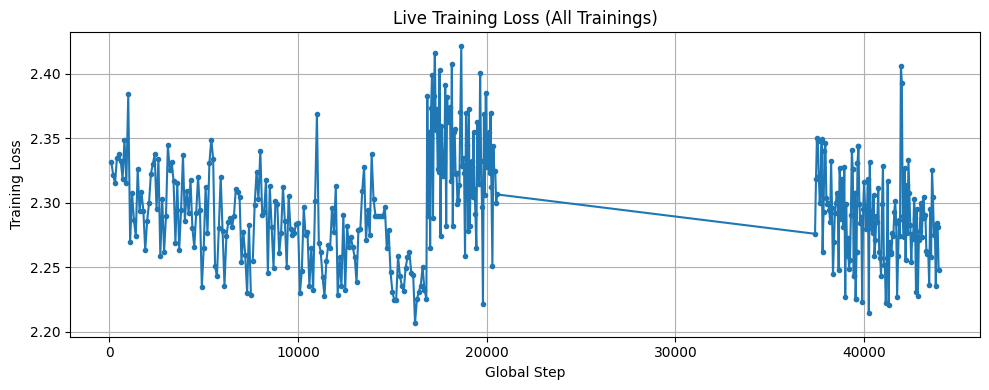

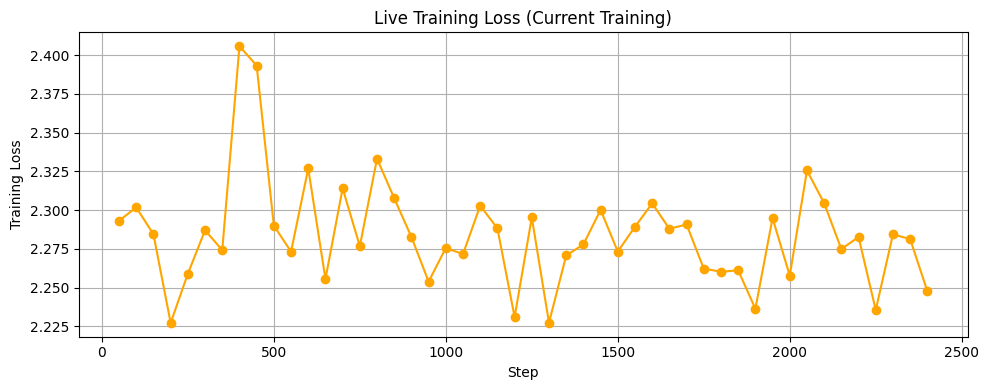

Loss log flushed to Hugging Face at step 43050


No files have been modified since last commit. Skipping to prevent empty commit.


Loss log flushed to Hugging Face at step 1500
Loss log flushed to Hugging Face at step 43100


<ipython-input-11-7a6d9f3eff7c>:24: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_all = pd.concat([


Loss log flushed to Hugging Face at step 43150


...

Loss log flushed to Hugging Face at step 2300
Loss log flushed to Hugging Face at step 43900


<ipython-input-11-7a6d9f3eff7c>:24: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_all = pd.concat([


Loss log flushed to Hugging Face at step 43950


No files have been modified since last commit. Skipping to prevent empty commit.


Loss log flushed to Hugging Face at step 2400


In [ ]:
torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()

HF_REPO_ID = "eduhuemar001/tinyllama-german-checkpoints"
resume_checkpoint = None

# Check if checkpoint exists
api = HfApi()
try:
    files = list_repo_files(repo_id=HF_REPO_ID, repo_type="model")
    checkpoints = [f for f in files if "checkpoint" in f]
    if checkpoints:
        print("Found checkpoint on Hugging Face Hub.")
        resume_checkpoint = HF_REPO_ID
    else:
        print("No checkpoint found.")
except Exception as e:
    print("Error checking checkpoint repo:", e)

# Train
start_time = time.time()
if resume_checkpoint:
    print(f"Resuming from HF checkpoint: {resume_checkpoint}")
    local_path = snapshot_download(
      repo_id="eduhuemar001/tinyllama-german-checkpoints",
      repo_type="model",
      local_dir="/content/hf-checkpoints",
    )

    # Resume from actual subfolder path
    resume_checkpoint = os.path.join(local_path, "last-checkpoint")
    trainer.train(resume_from_checkpoint=resume_checkpoint)
else:
    print("Starting fresh training...")
    trainer.train()
end_time = time.time()
print(f"Training took {end_time - start_time:.2f} seconds")

# Save LoRA adapter (not full model)
model.save_pretrained("tinyllama-german-lora")
tokenizer.save_pretrained("tinyllama-german-lora")

# Upload adapter only
api.upload_folder(
    folder_path="tinyllama-german-lora",
    repo_id="eduhuemar001/tinyllama-german",
    repo_type="model",
    commit_message="Uploading LoRA adapter after training."
)

# Delete HF checkpoint after successful training
try:
    print(f"Deleting checkpoint repo: {HF_REPO_ID}")
    delete_repo(repo_id=HF_REPO_ID, repo_type="model")
except Exception as e:
    print("Failed to delete checkpoint repo:", e)

## Appendix

#### Memory usage

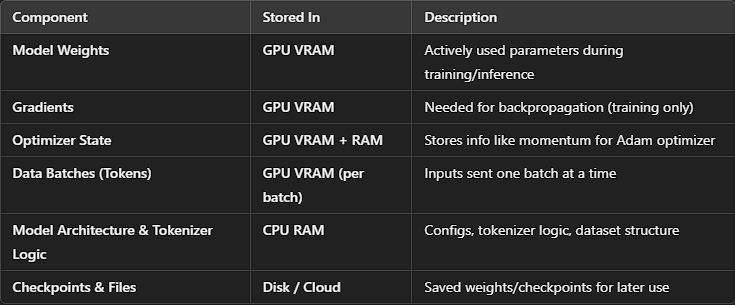